# Playing Around with Concrete for Regression
- The problem is siimply just to test the compressive strength (in MPa) of a concrete mixture.
- Various variables around the components to predict the compressive strength.

In [36]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV


import matplotlib.pyplot as plt


In [7]:
concrete = fetch_openml(name='concrete_compressive_strength', version=7, as_frame=True)

concrete_df = concrete['frame']
X = concrete['data']
y = concrete['target']

In [4]:
# 1).  Understand the dataset first.  See the makeup of the dataset
# 2).  Fill in gaps and/or drop rows.  
# 3).  Do a bit of EDA to understand the relationship between variables (especially plots)
# 4).  Split the data into a train and test set
# 5).  Normalize the dataset
# 6).  Run a few models (and possibly cross validation if enough data is available to do so)
# 7).  Measure accuracy or other appropriate metrics.

In [12]:
# Quick check for null values in both the target and the dataset itself.
y.isnull().sum()

np.int64(0)

In [13]:
concrete_df.isnull().sum()

cement                0
blast_furnace_slag    0
fly_ash               0
water                 0
superplasticizer      0
coarse_aggregate      0
fine_aggregate        0
age                   0
strength              0
dtype: int64

<Axes: >

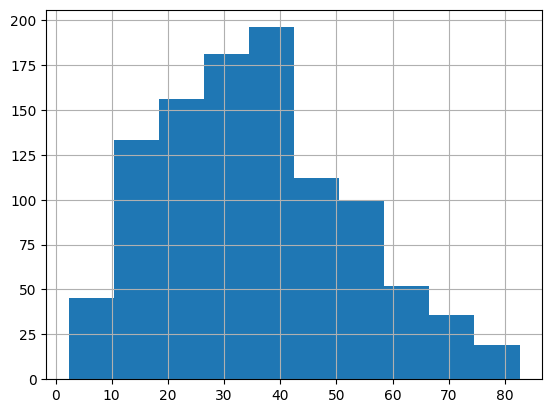

In [8]:
y.hist()

array([[<Axes: title={'center': 'cement'}>,
        <Axes: title={'center': 'blast_furnace_slag'}>,
        <Axes: title={'center': 'fly_ash'}>],
       [<Axes: title={'center': 'water'}>,
        <Axes: title={'center': 'superplasticizer'}>,
        <Axes: title={'center': 'coarse_aggregate'}>],
       [<Axes: title={'center': 'fine_aggregate'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'strength'}>]], dtype=object)

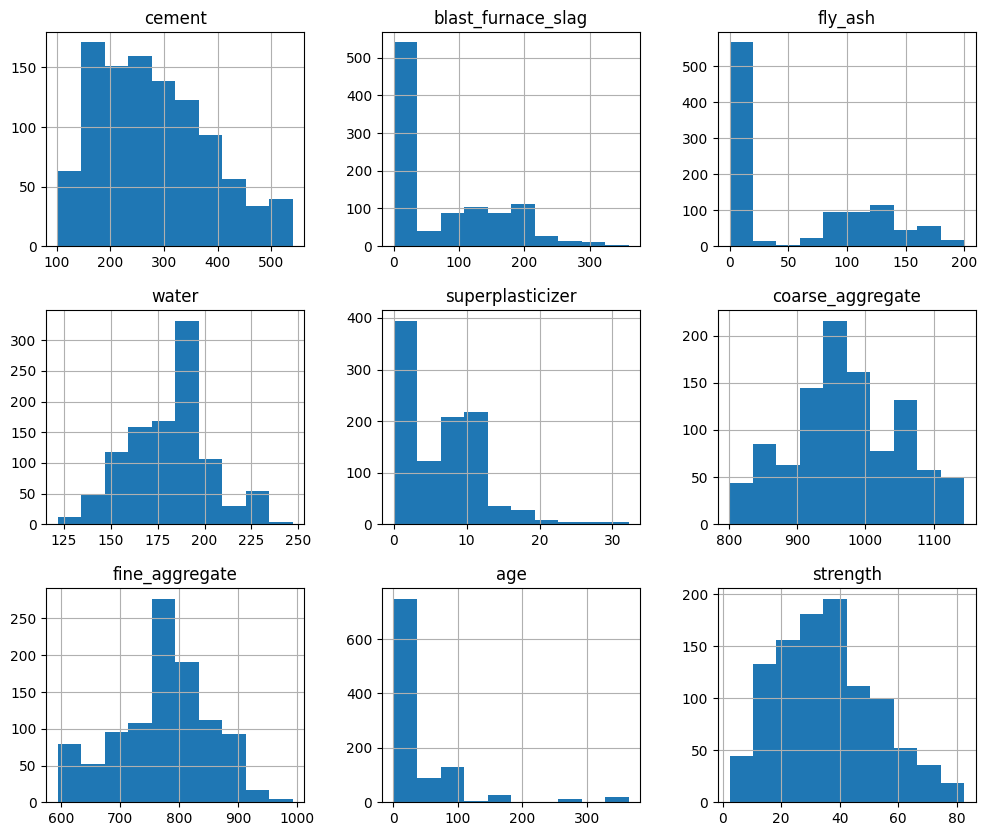

In [10]:
concrete_df.hist(figsize=(12,10))

In [11]:
# Blast furnace Slag and Age seems to have maybe a few outliers.  I think I'll take a look at these two.

concrete_df.isnull().sum()

cement                0
blast_furnace_slag    0
fly_ash               0
water                 0
superplasticizer      0
coarse_aggregate      0
fine_aggregate        0
age                   0
strength              0
dtype: int64

In [14]:
concrete_df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


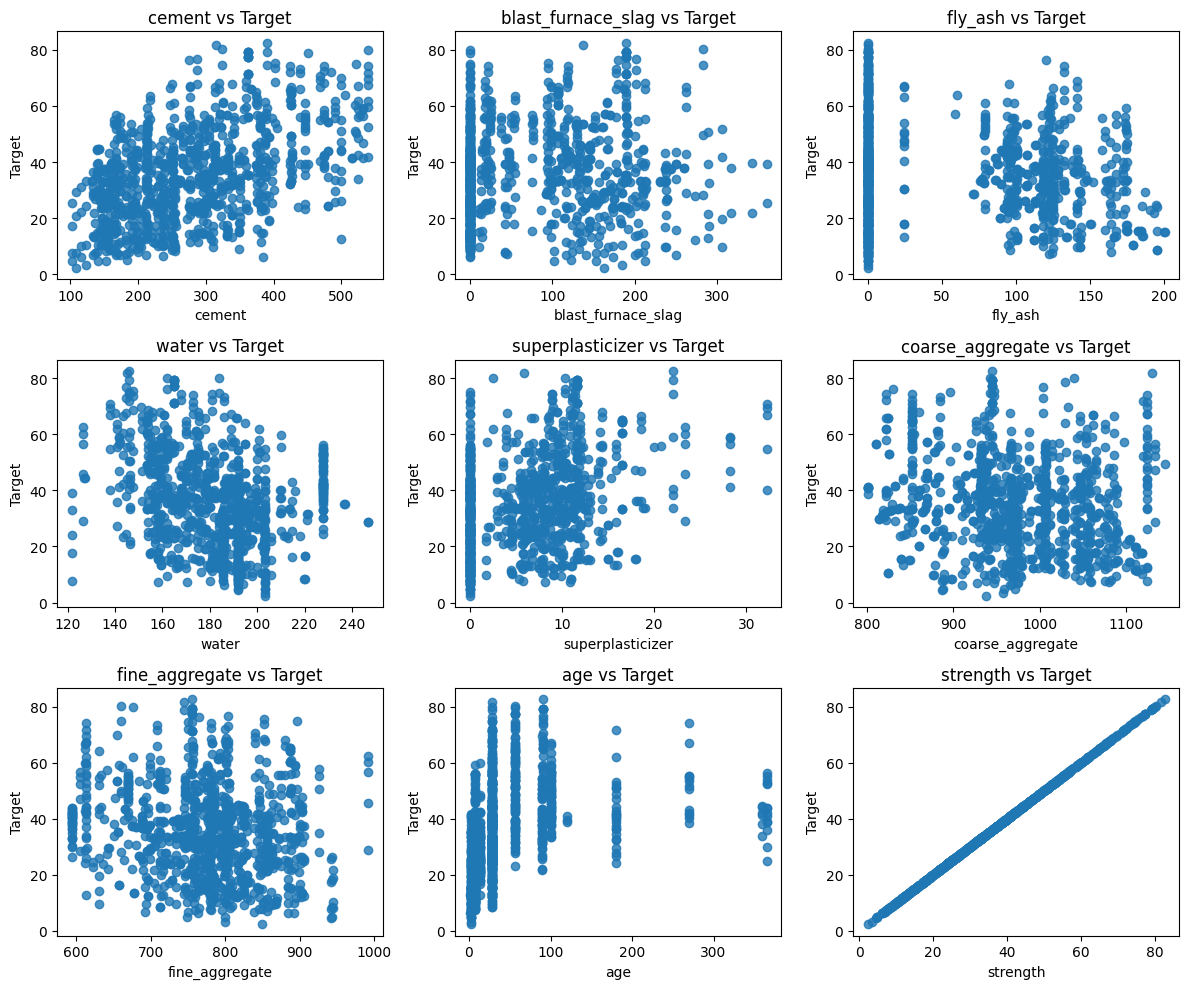

In [24]:
fig, axes = plt.subplots(3,3, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(concrete_df.columns):
    axes[i].scatter(concrete_df[col], y, alpha=0.8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Target')
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()

In [25]:
# So I see some relationship between the variables, and it's obvious that strength is the same as the target.
# This means that it needs to be left out of the dataset.

In [33]:
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.25)

In [35]:
# Normalize the train dataset.  Use the mean and std from these dataset in order to normalize the test dataset.

train_norm_x = (train_x - train_x.mean())/train_x.std()
test_norm_x = (test_x-test_x.mean())/train_x.std()


In [ ]:
# RidgeCV, LassoCV, ElasticNetCV
# Let's run and plot these three models quickly.

ridge_cv = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 2, 5, 10]).fit(train_norm_x, train_y)
best_alpha = ridge_cv.alpha_
best_score = ridge_cv.score(train_norm_x, train_y)

print(f'Best alpha is {best_alpha}')
print(f'Best score of {best_score}')

0.6226574369281457

In [53]:
lasso_cv = LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 2, 5, 10]).fit(train_norm_x, train_y)
best_alpha = lasso_cv.alpha_
best_score = lasso_cv.score(train_norm_x, train_y)

print(f'Best alpha is {best_alpha}')
print(f'Best score of {best_score}')

Best alpha is 0.1
Best score of 0.6217626578429472


In [58]:
elastic_cv = ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 2, 5, 10]).fit(train_norm_x, train_y)
best_alpha = elastic_cv.alpha_
best_score = elastic_cv.score(train_norm_x, train_y)

print(f'Best l1 ratio is {best_alpha}')
print(f'Best score of {best_score}')

Best l1 ratio is 0.001
Best score of 0.6227259659319307


Text(0.5, 1.0, 'Elastic Net (0.001), R² = 0.589')

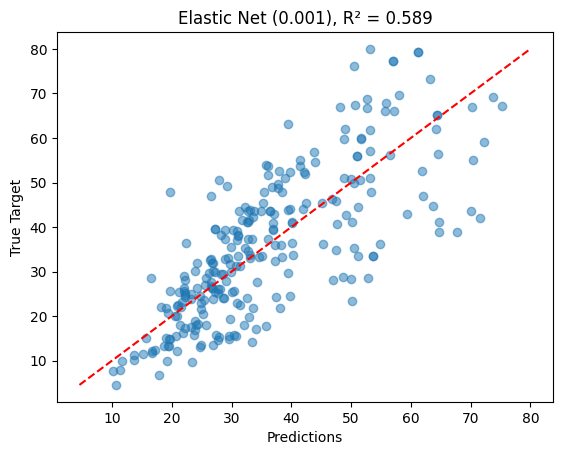

In [59]:
# Ok, so the best R**2 is elastic, so let's plot that one.

predictions = elastic_cv.predict(test_norm_x)
test_score = elastic_cv.score(test_norm_x, test_y)

plt.scatter(predictions, test_y, alpha=0.5)
plt.xlabel('Predictions')
plt.ylabel('True Target')
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--')
plt.title(f'Elastic Net ({best_alpha}), R² = {test_score:.3f}')


